In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#loading dataset
df=pd.read_csv("housing.csv")
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [2]:
# check missing values
df.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [3]:
#statistical summary
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [4]:
# data cleaning
df['total_bedrooms'] = df['total_bedrooms'].fillna(df['total_bedrooms'].median())

In [5]:
#remove duplicates
df=df.drop_duplicates()

In [6]:
#converting data types
df['housing_median_age']=df['housing_median_age'].astype(int)

In [8]:
#checking once nulls,datatypes
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  int32  
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20640 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(8), int32(1), object(1)
memory usage: 1.5+ MB


longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64

In [10]:
#analysis

# Average House Value by Location
df.groupby('ocean_proximity')['median_house_value'].mean().round(2)

ocean_proximity
<1H OCEAN     240084.29
INLAND        124805.39
ISLAND        380440.00
NEAR BAY      259212.31
NEAR OCEAN    249433.98
Name: median_house_value, dtype: float64

In [12]:
# Average Population by Area
df.groupby('ocean_proximity')['population'].mean().round(2)

ocean_proximity
<1H OCEAN     1520.29
INLAND        1391.05
ISLAND         668.00
NEAR BAY      1230.32
NEAR OCEAN    1354.01
Name: population, dtype: float64

In [17]:
# Total Income by Location
df.groupby('ocean_proximity')['median_income'].sum().round(2)

ocean_proximity
<1H OCEAN     38651.51
INLAND        21022.14
ISLAND           13.72
NEAR BAY       9555.91
NEAR OCEAN    10647.38
Name: median_income, dtype: float64

In [20]:
#Average Income by Location
df.groupby("ocean_proximity")["median_income"].mean().round(2)

ocean_proximity
<1H OCEAN     4.23
INLAND        3.21
ISLAND        2.74
NEAR BAY      4.17
NEAR OCEAN    4.01
Name: median_income, dtype: float64

In [21]:
# House per location
df['ocean_proximity'].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

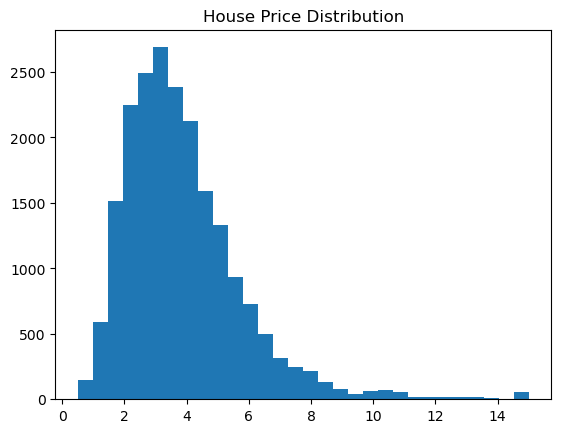

In [22]:
# visualization

# House Price Distribution
plt.hist(df['median_income'],bins=30)
plt.title("House Price Distribution")
plt.show()

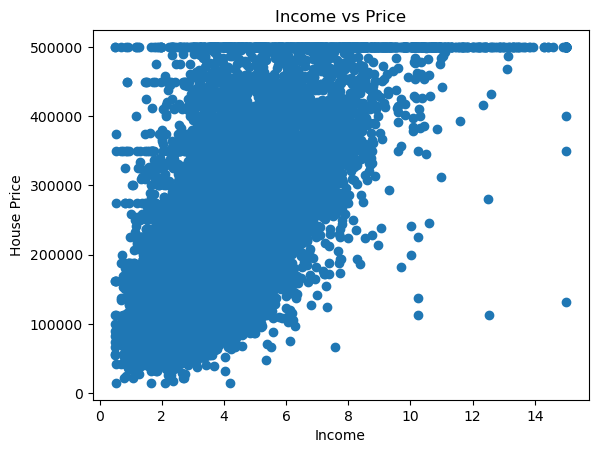

In [23]:
# Income vs Price
plt.scatter(df['median_income'],df['median_house_value'])
plt.xlabel("Income")
plt.ylabel("House Price")
plt.title("Income vs Price")
plt.show()

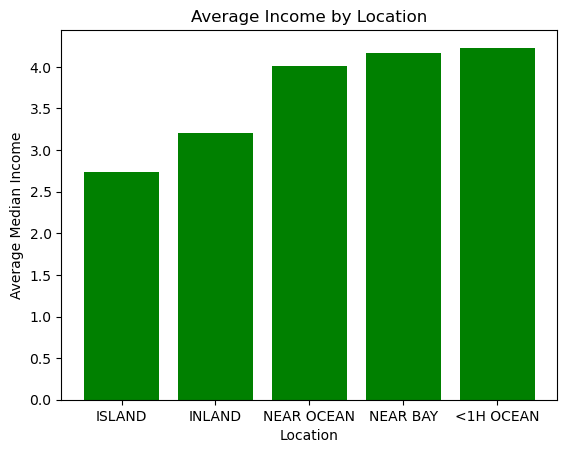

In [31]:
# Average Income by Location
income_by_location = df.groupby("ocean_proximity")["median_income"].mean().round(2).sort_values()

plt.bar(income_by_location.index, income_by_location.values,color='green')
plt.xlabel("Location")
plt.ylabel("Average Median Income")
plt.title("Average Income by Location")
plt.show()

In [32]:
# save cleaned dataset
df.to_csv("cleaned_housing.csv",index=False)